# Constrained Optimization

Minimize ‖p − target‖² subject to |p| = 2 using five strategies.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from jaxcad.constraints import (
    DistanceConstraint,
    Vector,
    constraint_residuals,
    make_manifold_projection,
    null_space,
)
from jaxcad.extraction import extract_parameters

## Setup

p₀ = (2, 0, 0), target = (1, 1.5, 0). `run` times N steps after a warm-up call to exclude JAX compilation.

In [2]:
anchor = Vector(jnp.array([0.0, 0.0, 0.0]))
p = Vector(jnp.array([2.0, 0.0, 0.0]), free=True, name="p")

distance_constraint = DistanceConstraint(anchor, p, distance=2.0)

target = jnp.array([1.0, 1.5, 0.0])

In [3]:
free_params, fixed_params, metadata = extract_parameters(distance_constraint)
print("free_params", free_params)
print("fixed_params", fixed_params)
print("metadata", metadata)

# Optimal constrained solution: project target onto |p|=2 sphere
p_star = target * (2.0 / jnp.linalg.norm(target))
optimal_loss = float(jnp.sum((p_star - target) ** 2))
print(f"p_star ≈ {np.array(p_star).round(3)},  optimal_loss = {optimal_loss:.4f}")

free_params {'p': Array([2., 0., 0.], dtype=float32)}
fixed_params {'distanceconstraint_0.param1': Array([0., 0., 0.], dtype=float32), 'distanceconstraint_0.distance': Array(2., dtype=float32, weak_type=True)}
metadata {'p': Vector(value=Array([2., 0., 0.], dtype=float32), free=True, name='p', bounds=None)}
p_star ≈ [1.109 1.664 0.   ],  optimal_loss = 0.0389


In [4]:
N_STEPS = 40
LAMBDA = 25.0


def full_objective(full):
    return jnp.sum((full[p.name] - target) ** 2)


def run(grad_fn, opt, full_init, n=N_STEPS):
    """Run n gradient steps.

    Always passes ``params=full`` to ``opt.update`` so transforms like
    ``make_manifold_projection`` that need the current params work correctly.
    Standard optax transforms (adam, etc.) simply ignore the extra kwarg.
    """
    opt_state = opt.init(full_init)
    grad_fn(full_init)  # warm-up to exclude JAX compilation time

    hist = {"loss": [], "violation": [], "cumtime": [], "traj": [np.array(full_init["p"])]}
    t0, full = time.perf_counter(), full_init
    for i in range(n):
        val, g = grad_fn(full)
        updates, opt_state = opt.update(g, opt_state, full)
        full = optax.apply_updates(full, updates)

        hist["loss"].append(float(val))
        hist["violation"].append(float(jnp.linalg.norm(constraint_residuals(full, metadata))))
        hist["cumtime"].append(time.perf_counter() - t0)
        hist["traj"].append(np.array(full["p"]))

        if i % 5 == 0:
            print(f"Step {i:2d}, loss {val:.4f}, |r| {hist['violation'][-1]:.4f}")

    return hist, full

## Fixed null-space projection

N computed once at x₀; gradient projected onto NNᵀ each step.

In [5]:
def loss_ns_fixed(reduced_vector, N):
    return full_objective(N @ reduced_vector)


value_and_grad_ns_fixed = jax.value_and_grad(loss_ns_fixed)
N_fixed = null_space(free_params, metadata)


def grad_ns_fixed(full: dict):
    reduced = full @ N_fixed
    loss, g_reduced = value_and_grad_ns_fixed(reduced, N_fixed)
    return loss, N_fixed @ g_reduced


optimizer = optax.adam(learning_rate=0.05)

h_ns_fixed, end_ns_fixed = run(grad_ns_fixed, opt=optimizer, full_init=free_params)

Step  0, loss 3.2500, |r| 0.0006
Step  5, loss 2.5647, |r| 0.0221
Step 10, loss 2.0142, |r| 0.0718
Step 15, loss 1.5998, |r| 0.1431
Step 20, loss 1.3132, |r| 0.2274
Step 25, loss 1.1365, |r| 0.3146
Step 30, loss 1.0441, |r| 0.3952
Step 35, loss 1.0072, |r| 0.4619


## Relinearized null-space projection

N recomputed at the current point each step so the gradient is projected onto the tangent plane at the *current* position, not just the initial one. Plain SGD is used rather than Adam: Adam's element-wise adaptive scaling distorts the step as the null space rotates (components that were zero acquire non-zero projections and get amplified). Violation still accumulates because steps along the tangent plane leave the curved manifold by O(lr²κ) with no correction.

In [6]:
value_and_grad_full = jax.value_and_grad(full_objective)


def grad_ns_relin(full: dict):
    N = null_space(full, metadata)
    loss, g = value_and_grad_full(full)
    return loss, N @ (g @ N)  # project gradient onto current tangent space


# Use plain SGD, not Adam: Adam's element-wise adaptive scaling amplifies components
# that are newly introduced as the null space rotates, pushing steps off the tangent plane.
h_ns_relin, end_ns_relin = run(grad_ns_relin, opt=optax.sgd(0.15), full_init=free_params)

Step  0, loss 3.2500, |r| 0.0500
Step  5, loss 0.3380, |r| 0.1287
Step 10, loss 0.1223, |r| 0.1338
Step 15, loss 0.1104, |r| 0.1340
Step 20, loss 0.1098, |r| 0.1340
Step 25, loss 0.1097, |r| 0.1340
Step 30, loss 0.1097, |r| 0.1340
Step 35, loss 0.1097, |r| 0.1340


## Manifold projection via `make_manifold_projection`

Chain `make_manifold_projection(metadata)` after any optax optimizer. On each call to `optimizer.update(grads, state, params)` it computes `new_params = params + adam_update`, projects onto the constraint manifold via a Newton correction, then returns `projected − params` as the effective update — so `apply_updates(params, updates)` lands exactly on the manifold. The `run` loop passes `params=full` to every `opt.update` call, which is what activates the projection.

In [7]:
optimizer_proj = optax.chain(optax.adam(0.05), make_manifold_projection(metadata))

value_and_grad_proj = jax.value_and_grad(full_objective)


def grad_proj(full):
    return value_and_grad_proj(full)


h_proj, end_proj = run(grad_proj, opt=optimizer_proj, full_init=free_params)

Step  0, loss 3.2500, |r| 0.0000
Step  5, loss 2.4846, |r| 0.0000
Step 10, loss 1.7493, |r| 0.0000
Step 15, loss 1.1098, |r| 0.0000
Step 20, loss 0.6186, |r| 0.0000
Step 25, loss 0.2950, |r| 0.0000
Step 30, loss 0.1201, |r| 0.0000
Step 35, loss 0.0508, |r| 0.0000


## Riemannian gradient descent (relinearized + projection)

Combine both ideas: step along the *current* tangent plane (`grad_ns_relin`) then snap back to the manifold with `make_manifold_projection`. This is the hybrid — it gets the correct manifold-aware gradient direction *and* enforces the constraint exactly after every step. Chaining `optax.sgd` with `make_manifold_projection` requires no new code.

In [8]:
optimizer_riem = optax.chain(optax.sgd(0.15), make_manifold_projection(metadata))

h_riem, end_riem = run(grad_ns_relin, opt=optimizer_riem, full_init=free_params)

Step  0, loss 3.2500, |r| 0.0000
Step  5, loss 0.2350, |r| 0.0000
Step 10, loss 0.0475, |r| 0.0000
Step 15, loss 0.0393, |r| 0.0000
Step 20, loss 0.0389, |r| 0.0000
Step 25, loss 0.0389, |r| 0.0000
Step 30, loss 0.0389, |r| 0.0000
Step 35, loss 0.0389, |r| 0.0000


## Penalty method

Augmented loss: ‖p − t‖² + λ‖r(p)‖². Penalty Hessian eigenvalue in the normal direction is 2 + 2λ; stable LR ≤ 1/(1 + 2λ).

In [9]:
LR_PENALTY = 2.5 / (1.0 + 2.0 * LAMBDA)
optimizer_penalty = optax.adam(learning_rate=LR_PENALTY)


def loss_penalty(full):
    return full_objective(full) + LAMBDA * jnp.sum(constraint_residuals(full, metadata) ** 2)


value_and_grad_penalty = jax.value_and_grad(loss_penalty)


def grad_penalty(full):
    val = full_objective(full)
    _, g = value_and_grad_penalty(full)
    return val, g


h_penalty, end_penalty = run(grad_penalty, opt=optimizer_penalty, full_init=free_params)
print(f"final loss={h_penalty['loss'][-1]:.4f}  violation={h_penalty['violation'][-1]:.2e}")

Step  0, loss 3.2500, |r| 0.0484
Step  5, loss 2.5040, |r| 0.0102
Step 10, loss 1.8465, |r| 0.0424
Step 15, loss 1.3065, |r| 0.0186
Step 20, loss 0.8607, |r| 0.0191
Step 25, loss 0.4898, |r| 0.0206
Step 30, loss 0.2535, |r| 0.0066
Step 35, loss 0.1052, |r| 0.0109
final loss=0.0511  violation=8.36e-03


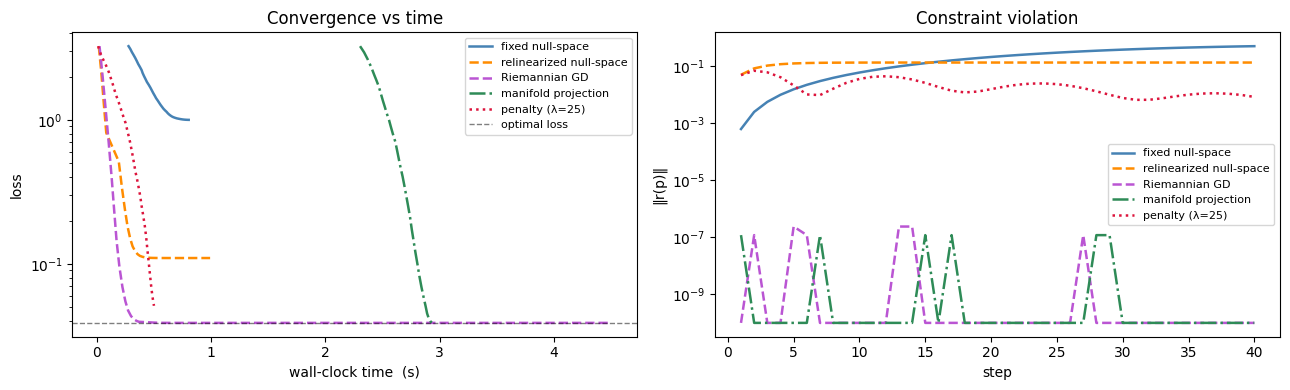

In [10]:
STYLES = {
    "fixed null-space": (h_ns_fixed, "steelblue", "-", "o"),
    "relinearized null-space": (h_ns_relin, "darkorange", "--", "s"),
    "Riemannian GD": (h_riem, "mediumorchid", "--", "P"),
    "manifold projection": (h_proj, "seagreen", "-.", "^"),
    f"penalty (λ={LAMBDA:.0f})": (h_penalty, "crimson", ":", "D"),
}

FLOOR = 1e-10

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for label, (h, color, ls, _) in STYLES.items():
    ax.semilogy(h["cumtime"], h["loss"], color=color, linestyle=ls, lw=1.8, label=label)
ax.axhline(optimal_loss, color="black", ls="--", lw=1, alpha=0.5, label="optimal loss")
ax.set_xlabel("wall-clock time  (s)")
ax.set_ylabel("loss")
ax.set_title("Convergence vs time")
ax.legend(fontsize=8)

ax = axes[1]
for label, (h, color, ls, _) in STYLES.items():
    v = [max(x, FLOOR) for x in h["violation"]]
    ax.semilogy(range(1, len(v) + 1), v, color=color, linestyle=ls, lw=1.8, label=label)
ax.set_xlabel("step")
ax.set_ylabel("‖r(p)‖")
ax.set_title("Constraint violation")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

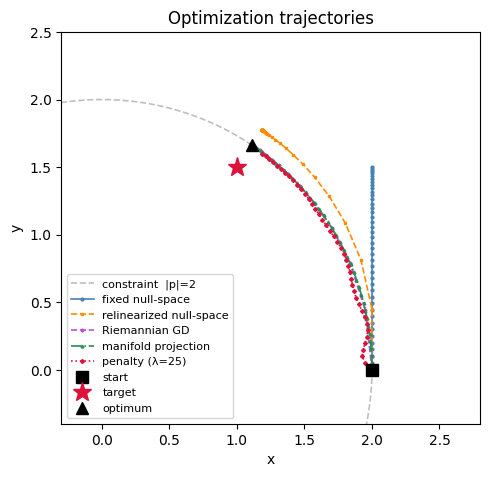

In [11]:
theta = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(
    2 * np.cos(theta),
    2 * np.sin(theta),
    "--",
    color="gray",
    alpha=0.5,
    lw=1.2,
    label="constraint  |p|=2",
)

x0_arr = np.array(free_params["p"])
for label, (h, color, ls, marker) in STYLES.items():
    traj = np.array(h["traj"])
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        color=color,
        linestyle=ls,
        marker=marker,
        markersize=2,
        lw=1.2,
        label=label,
    )

ax.plot(*x0_arr[:2], "s", color="black", ms=9, zorder=6, label="start")
ax.plot(*np.array(target)[:2], "*", color="crimson", ms=14, zorder=6, label="target")
ax.plot(*np.array(p_star)[:2], "^", color="black", ms=9, zorder=6, label="optimum")
ax.set_xlim(-0.3, 2.8)
ax.set_ylim(-0.4, 2.5)
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("Optimization trajectories")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()